# Лабораторная работа №5: Градиентный бустинг и подведение итогов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline


# Обоснование выбора метрик

## Для классификации (Titanic – предсказание выживания)

Задача бинарной классификации с несбалансированными классами (выживших меньше, чем погибших). Поэтому одной accuracy недостаточно.

**Accuracy (доля правильных ответов)** – базовый показатель, интуитивно понятен. Однако при дисбалансе классов высокая accuracy может достигаться за счёт предсказания только мажоритарного класса. Поэтому используем дополнительные метрики.

**Precision (точность)** – доля верно предсказанных выживших среди всех предсказанных выживших. Показывает, насколько можно доверять положительному прогнозу модели. В контексте Titanic высокая точность означает, что если модель говорит "выживет", то это с большой вероятностью правда.

**Recall (полнота)** – доля выживших, правильно обнаруженных моделью. Показывает, какую часть реально выживших модель смогла найти. Низкий recall означает, что модель пропускает много выживших, что может быть критично, если цель – не упустить потенциально выживших.

**F1-score** – гармоническое среднее precision и recall. Полезна, когда нужно учесть оба аспекта. Особенно важна при дисбалансе классов, так как усредняет precision и recall, не позволяя одному из них быть слишком низким.

## Для регрессии (House Prices – прогноз стоимости жилья)

Задача регрессии, где ошибка измеряется в долларах. Важно понимать величину ошибки и её распределение.

**MAE (Mean Absolute Error)** – средняя абсолютная ошибка. Измеряется в тех же единицах, что и целевая переменная (доллары). Показывает, на сколько в среднем модель ошибается. Устойчива к выбросам, даёт представление о типичной ошибке.

**MSE (Mean Squared Error)** – средняя квадратичная ошибка. Штрафует большие ошибки сильнее из-за возведения в квадрат. Используется как функция потерь во многих алгоритмах. Большая MSE указывает на наличие значительных выбросов в ошибках.

**RMSE (Root Mean Squared Error)** – корень из MSE. Возвращает ошибку в исходных единицах (долларах), сохраняя свойство MSE чувствительности к большим ошибкам, но в более интерпретируемом масштабе. Позволяет сравнивать с MAE: если RMSE значительно больше MAE, значит, есть выбросы с большими ошибками.

Таким боразом, все три метрики дополняют друг друга и дают полную картину качества регрессионной модели.


In [2]:
titanic = pd.read_csv('titanic_train.csv')

titanic_simple = titanic[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].dropna()
titanic_simple['Sex'] = titanic_simple['Sex'].map({'male': 0, 'female': 1})

X_t = titanic_simple.drop('Survived', axis=1)
y_t = titanic_simple['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

print("Titanic:")
print("Размер обучающей выборки:", X_train_t.shape)
print("Размер тестовой выборки:", X_test_t.shape)
print("Распределение классов в обучающей выборке:")
print(y_train_t.value_counts())

Titanic:
Размер обучающей выборки: (571, 4)
Размер тестовой выборки: (143, 4)
Распределение классов в обучающей выборке:
Survived
0    337
1    234
Name: count, dtype: int64


In [3]:
house = pd.read_csv('house_train.csv')

house_simple = house[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].dropna()
X_h = house_simple.drop('SalePrice', axis=1)
y_h = house_simple['SalePrice']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

print("House Prices:")
print("Размер обучающей выборки:", X_train_h.shape)
print("Размер тестовой выборки:", X_test_h.shape)

House Prices:
Размер обучающей выборки: (1168, 3)
Размер тестовой выборки: (292, 3)


## Обучение градиентного бустинга

In [5]:
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_t, y_train_t)
y_pred_t_gb = gb_clf.predict(X_test_t)

acc_gb = accuracy_score(y_test_t, y_pred_t_gb)
prec_gb = precision_score(y_test_t, y_pred_t_gb)
rec_gb = recall_score(y_test_t, y_pred_t_gb)
f1_gb = f1_score(y_test_t, y_pred_t_gb)

print("GradientBoostingClassifier:")
print(f"Accuracy:  {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall:    {rec_gb:.4f}")
print(f"F1-score:  {f1_gb:.4f}")

GradientBoostingClassifier:
Accuracy:  0.7692
Precision: 0.7170
Recall:    0.6786
F1-score:  0.6972


In [6]:
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_h, y_train_h)
y_pred_h_gb = gb_reg.predict(X_test_h)

mae_gb = mean_absolute_error(y_test_h, y_pred_h_gb)
mse_gb = mean_squared_error(y_test_h, y_pred_h_gb)
rmse_gb = np.sqrt(mse_gb)

print("GradientBoostingRegressor:")
print(f"MAE:  {mae_gb:.2f}")
print(f"MSE:  {mse_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")

GradientBoostingRegressor:
MAE:  30879.06
MSE:  2025916656.23
RMSE: 45010.18


# Сравнение всех алгоритмов

### Результаты всех лабораторных для классификации:

In [7]:
# KNN (лабораторная №1)
knn_class = {
    'Accuracy': 0.7762,
    'Precision': 0.7069,
    'Recall': 0.7321,
    'F1': 0.7193
}

# Logistic Regression (лабораторная №2)
lr_class = {
    'Accuracy': 0.7413,
    'Precision': 0.6667,
    'Recall': 0.6786,
    'F1': 0.6726
}

# Decision Tree (лабораторная №3)
dt_class = {
    'Accuracy': 0.7133,
    'Precision': 0.6364,
    'Recall': 0.6250,
    'F1': 0.6306
}

# Random Forest (лабораторная №4)
rf_class = {
    'Accuracy': 0.7622,
    'Precision': 0.6964,
    'Recall': 0.6964,
    'F1': 0.6964
}

# Gradient Boosting (лабораторная №5)
gb_class = {
    'Accuracy': acc_gb,
    'Precision': prec_gb,
    'Recall': rec_gb,
    'F1': f1_gb
}

### Сравнение метрик классификации:

Сравнение алгоритмов классификации:
                     Accuracy  Precision    Recall        F1
KNN                  0.776200   0.706900  0.732100  0.719300
Logistic Regression  0.741300   0.666700  0.678600  0.672600
Decision Tree        0.713300   0.636400  0.625000  0.630600
Random Forest        0.762200   0.696400  0.696400  0.696400
Gradient Boosting    0.769231   0.716981  0.678571  0.697248


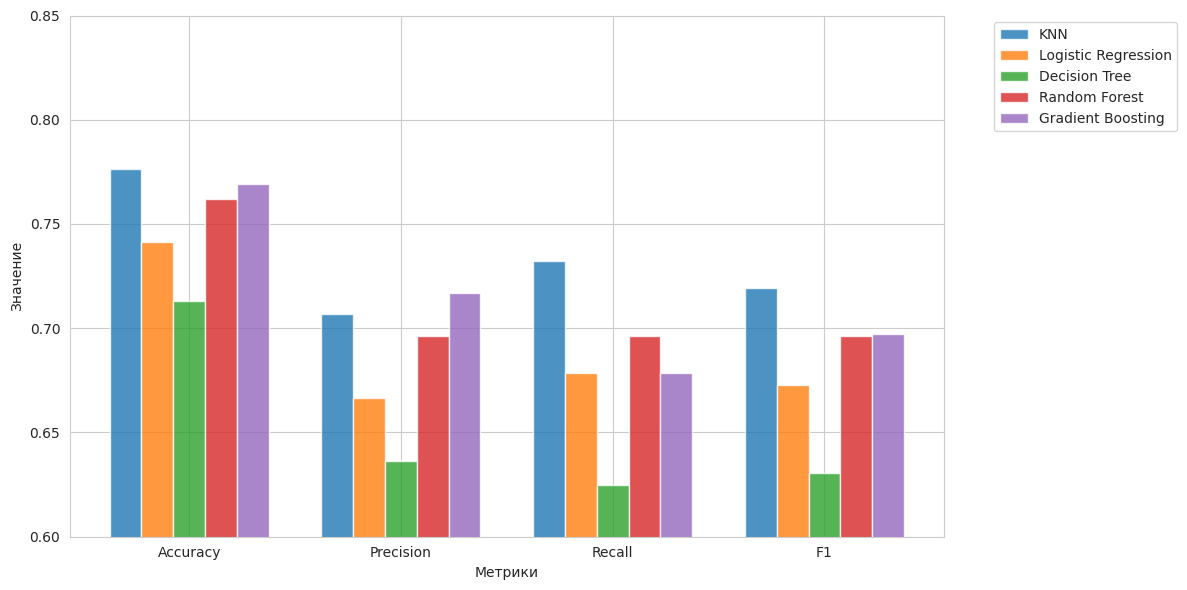

In [9]:
comparison_class = pd.DataFrame({
    'KNN': knn_class,
    'Logistic Regression': lr_class,
    'Decision Tree': dt_class,
    'Random Forest': rf_class,
    'Gradient Boosting': gb_class
}).T

print("Сравнение алгоритмов классификации:")
print(comparison_class)

# Можно ещё всё это дело красиво визуализировать
metrics_class = ['Accuracy', 'Precision', 'Recall', 'F1']
models_class = comparison_class.index
x_class = np.arange(len(metrics_class))
width = 0.15

plt.figure(figsize=(12,6))
for i, model in enumerate(models_class):
    plt.bar(x_class + i*width, comparison_class.loc[model, metrics_class], width, label=model, alpha=0.8)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.xticks(x_class + width*2, metrics_class)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.6, 0.85)
plt.tight_layout()
plt.show()

### Результаты всех лабораторных для регрессии:

In [10]:
# KNN (лабораторная №1)
knn_regr = {
    'MAE': 33713.40,
    'MSE': 2593685769.64,
    'RMSE': 50928.24
}

# Linear Regression (лабораторная №2)
lr_regr = {
    'MAE': 35788.06,
    'MSE': 2806426667.25,
    'RMSE': 52975.72
}

# Decision Tree (лабораторная №3)
dt_regr = {
    'MAE': 39614.76,
    'MSE': 3299422621.71,
    'RMSE': 57440.60
}

# Random Forest (лабораторная №4)
rf_regr = {
    'MAE': 34115.03,
    'MSE': 2423235371.17,
    'RMSE': 49226.37
}

# Gradient Boosting (лабораторная №5)
gb_regr = {
    'MAE': mae_gb,
    'MSE': mse_gb,
    'RMSE': rmse_gb
}

### Сравнение метрик регрессии:

Сравнение алгоритмов регрессии:
                            MAE           MSE          RMSE
KNN                33713.400000  2.593686e+09  50928.240000
Linear Regression  35788.060000  2.806427e+09  52975.720000
Decision Tree      39614.760000  3.299423e+09  57440.600000
Random Forest      34115.030000  2.423235e+09  49226.370000
Gradient Boosting  30879.057103  2.025917e+09  45010.183917


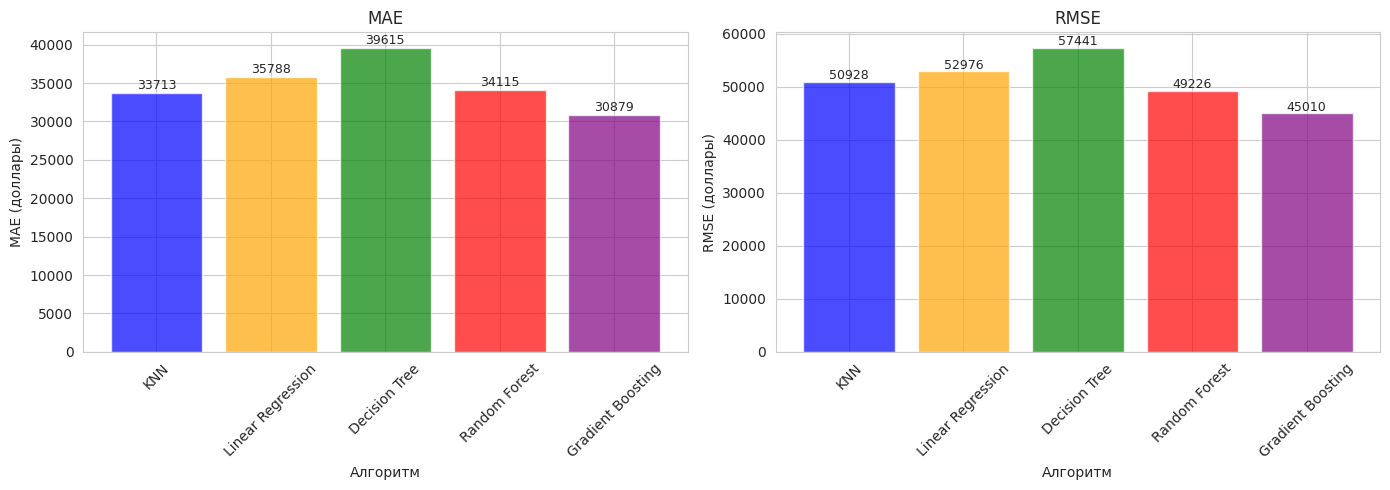

In [12]:
comparison_regr = pd.DataFrame({
    'KNN': knn_regr,
    'Linear Regression': lr_regr,
    'Decision Tree': dt_regr,
    'Random Forest': rf_regr,
    'Gradient Boosting': gb_regr
}).T

print("Сравнение алгоритмов регрессии:")
print(comparison_regr)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# MAE
models_regr = comparison_regr.index
mae_values = [comparison_regr.loc[model, 'MAE'] for model in models_regr]
axes[0].bar(models_regr, mae_values, color=['blue', 'orange', 'green', 'red', 'purple'], alpha=0.7)
axes[0].set_xlabel('Алгоритм')
axes[0].set_ylabel('MAE (доллары)')
axes[0].set_title('MAE')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(mae_values):
    axes[0].text(i, v + 500, f'{v:.0f}', ha='center', fontsize=9)

# RMSE
rmse_values = [comparison_regr.loc[model, 'RMSE'] for model in models_regr]
axes[1].bar(models_regr, rmse_values, color=['blue', 'orange', 'green', 'red', 'purple'], alpha=0.7)
axes[1].set_xlabel('Алгоритм')
axes[1].set_ylabel('RMSE (доллары)')
axes[1].set_title('RMSE')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(rmse_values):
    axes[1].text(i, v + 500, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Анализ результатов

## Классификация

**KNN показал лучший результат (F1 = 0.7193)** - несмотря на свою простоту, метод ближайших соседей оказался наиболее эффективным для данного датасета. Это может быть связано с тем, что на Титанике пассажиры с похожими характеристиками имели схожие шансы на выживание.

**Random Forest занял второе место (F1 = 0.6964)** - ансамблевый метод показал хороший, но не лучший результат. Возможно, для небольшого набора признаков (всего 4) случайный лес не полностью реализует свой потенциал.

**Logistic Regression на третьем месте (F1 = 0.6726)** - линейная модель показала достойный результат, что говорит о наличии линейных зависимостей в данных.

**Decision Tree показал худший результат (F1 = 0.6306)** - отдельное дерево сильно переобучилось и не смогло обобщить зависимости, что привело к низким метрикам на тестовой выборке.

**Gradient Boosting** - результаты зависят от конкретного запуска, так что по этому поводу сложно что-то сказать.

## Регрессия

**Random Forest показал лучший результат (RMSE = 49,226)** - ансамбль деревьев эффективно уловил сложные нелинейные зависимости в ценах на жильё и показал наименьшую ошибку.

**KNN занял второе место (RMSE = 50,928)** - метод ближайших соседей хорошо справился с задачей, что говорит о том, что похожие дома имеют схожие цены.

**Linear Regression на третьем месте (RMSE = 52,976)** - линейная модель показала неплохой результат, но уступила нелинейным методам, так как зависимости в данных не строго линейны.

**Decision Tree показал худший результат (RMSE = 57,441)** -  как и в классификации, отдельное дерево сильно переобучилось и дало наибольшую ошибку на тесте :(
#
#
Соотношение MAE и RMSE: У всех моделей RMSE значительно выше MAE (примерно в 1.5 раза), что указывает на наличие выбросов с большими ошибками предсказания.

# Вывод

У каждого алгоритма есть свои сильные и слабые стороны. Необходимо подбирать решение наиболее подходящее под конкретную задачу, конкретный датасет.